
Kernel: linear
Accuracy: 0.97
Confusion Matrix:
 [[25  1]
 [ 1 33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        26
           1       0.97      0.97      0.97        34

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60


Kernel: poly
Accuracy: 0.88
Confusion Matrix:
 [[26  0]
 [ 7 27]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      1.00      0.88        26
           1       1.00      0.79      0.89        34

    accuracy                           0.88        60
   macro avg       0.89      0.90      0.88        60
weighted avg       0.91      0.88      0.88        60


Kernel: rbf
Accuracy: 0.97
Confusion Matrix:
 [[25  1]
 [ 1 33]]
Classification Report:
               precision    recall  f1-score   support

           0     

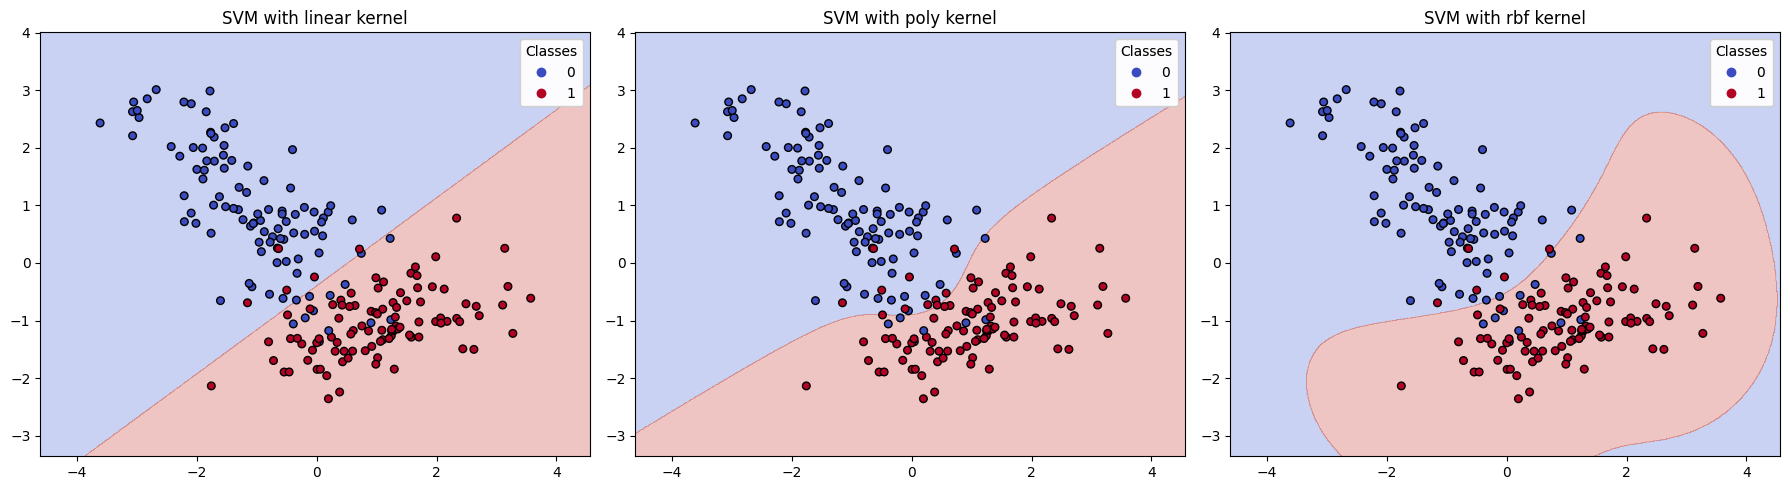

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import crepe
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler


np.random.seed(445)
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

kernels = ['linear', 'poly', 'rbf']
models = {}

for kernel in kernels:
    model = SVC(kernel=kernel, degree=3 if kernel == 'poly' else 1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    models[kernel] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'conf_matrix': confusion_matrix(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred)
    }

for kernel, data in models.items():
    print(f"\nKernel: {kernel}")
    print(f"Accuracy: {data['accuracy']:.2f}")
    print("Confusion Matrix:\n", data['conf_matrix'])
    print("Classification Report:\n", data['classification_report'])

# comment out below if using more than 2 features:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, kernel in enumerate(kernels):
    model = models[kernel]['model']
    ax = axes[i]
    ax.set_title(f"SVM with {kernel} kernel")

    # create meshgrid for decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # plot decision boundary and points
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=30, edgecolor='k')
    legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
    ax.add_artist(legend1)

plt.tight_layout()
plt.show()

/bin/bash: line 1: ageck314: No such file or directory
